# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ORM_AI_Agents_Bootcamp/blob/main/hands_on/DAY_1_HANDS_ON_SESSION_2_ToT.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://learning.oreilly.com/library/view/ai-agents-the/0642572247775/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="AI Agents Book – Read on O'Reilly"/>
</a>





<font color="red" size="10">
<b>HANDS-ON TIME: 15 mins</b>
</font>


# About this notebook

This notebook walks through a small but complete multi agent writing workflow that plans, researches, and drafts a developer focused blog post. It combines structured outputs, a tool using research step, and a simple LangGraph pipeline with checkpoints.

## What it shows

* **A four stage graph**

  1. **propose** generates three creative options with structured output
  2. **reflect** critiques and selects the best option with a stronger judge
  3. **research** uses OpenAI web search to collect sources and synthesize JSON
  4. **draft** produces a final outline and intro for the chosen plan
* **Separation of roles and models**

  * a small creative generator
  * a stricter judge
  * a tool bound researcher
  * a small writer for the final draft
* **Typed state** with accumulated messages, option and choice JSON, synthesized sources, and the final draft
* **In memory checkpoints** with `MemorySaver`
* **Readable streaming trace** that prints per node updates during execution
* **Graph preview** via Mermaid PNG

## What you will run

1. Load `OPENAI_API_KEY` from `.env`.
2. Define an `internet_search` tool that returns compact JSON results using OpenAI `web_search`.
3. Create Pydantic schemas for options, choice, and queries to keep outputs structured.
4. Wire a **linear LangGraph** with four nodes and compile it with a checkpointer.
5. Start a run with a topic prompt and watch the system stream updates from each node.
6. Inspect the final draft and render the graph image.

## How it works

* **Propose options** uses `with_structured_output(OptionsPayload)` to force three options with consistent fields.
* **Reflect and select** uses a stronger model with `ChoicePayload` to pick the best option by index with a rationale. The code clamps the index defensively.
* **Research with tools**

  * the researcher proposes 1 to 2 focused queries tied to the chosen option
  * the notebook calls `internet_search` for each query and collects raw findings
  * a compact synthesis step turns findings into a clean `sources_json` payload with suggested citations
* **Draft outline and intro** converts the chosen plan and sources into a title, audience sentence, a five section outline, and a short intro.

## Why this pattern

* Clear role separation improves quality and transparency. Generation, evaluation, research, and writing are handled by different prompts and sometimes different models.
* Structured outputs reduce ambiguity and make routing trivial.
* Tool use is explicit and observable which makes the process auditable.
* LangGraph keeps control flow readable and provides thread scoped memory with almost no boilerplate.

## Extend and adapt

* Add domain filters or user location to the OpenAI web search tool.
* Add a factuality checker or citation verifier between research and drafting.
* Persist checkpoints to a database for long running projects.
* Add a final formatter node that turns the draft into Markdown or HTML.

## Requirements and notes

* `OPENAI_API_KEY` is required.
* Internet results change over time. Expect different sources on different runs.
* The creative model is set slightly higher temperature. The judge is near zero for stability.
* Token and API costs can add up when streaming multiple stages.

## Intended audience

Engineers, technical writers, and researchers who want a practical template for a small, role based writing agent that mixes structured planning, tool assisted research, and drafting inside a simple LangGraph workflow.


# Open in Colab
<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ai-agents-the-definitive-guide/blob/main/CH02/ch02_ToT.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Dependencies

In [1]:
!pip install -q langchain==0.3.27 \
                langgraph==0.6.7 \
                langchain-openai==0.3.32 \
                langchain_experimental==0.3.4 \
                langchain_community==0.3.29 \
                python-dotenv==1.0.1 \
                langchain-core==0.3.75 \
                openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.0/444.0 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

# API Setup

In [2]:
# --- API Key Setup ---
# Option 1 (preferred): create a `.env` file in your project folder with:
# OPENAI_API_KEY=your_openai_key_here
#
# Option 2: set it directly in the notebook with magic:
# %env OPENAI_API_KEY=your_openai_key_here

from dotenv import load_dotenv
import os

# Load from .env if available
load_dotenv()

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

# Fallback: ask if still missing
if not OPENAI_API_KEY:
    print("⚠️ OPENAI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    OPENAI_API_KEY = input("Enter your OPENAI_API_KEY: ").strip()

print("✅ OPENAI_API_KEY loaded successfully!")



✅ OPENAI_API_KEY loaded successfully!


# Imports

In [3]:
import os, json, uuid, re, time
from typing import Annotated, List, TypedDict

from pydantic import BaseModel, Field
from openai import OpenAI

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, ToolMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

# Tool: internet_search

In [4]:
@tool("internet_search")
def internet_search(query: str) -> str:
    """Search web via OpenAI web_search. Returns compact JSON list."""
    key = os.getenv("OPENAI_API_KEY")
    if not key:
        return "[]"

    client = OpenAI(api_key=key)
    response = client.responses.create(
        model="gpt-4.1-mini",
        tools=[{"type": "web_search"}],
        input=(
            "Return ONLY a JSON array with up to 5 search results for this query. "
            "Each item must have: title, link, snippet, source. "
            f"Query: {query}"
        ),
    )

    text = (getattr(response, "output_text", "") or "").strip()
    if text.startswith("```"):
        m = re.search(r"```(?:json)?\s*(.*?)\s*```", text, flags=re.DOTALL)
        if m:
            text = m.group(1).strip()

    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            out = []
            for r in parsed[:5]:
                out.append({
                    "title": (r or {}).get("title"),
                    "link": (r or {}).get("link") or (r or {}).get("url"),
                    "snippet": (r or {}).get("snippet"),
                    "source": (r or {}).get("source"),
                })
            return json.dumps(out, ensure_ascii=False)
    except Exception:
        pass

    return "[]"

tools = [internet_search]

# Models: small generator, stronger judge, tool-bound researcher

In [5]:
baseline_llm  = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)   # single-shot baseline
gen_llm       = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)   # creative, cheaper
judge_llm     = ChatOpenAI(model="gpt-4o", temperature=0.2)        # stricter judge
research_llm  = ChatOpenAI(model="gpt-4o-mini", temperature=0.2).bind_tools(tools, tool_choice="auto")
writer_llm    = gen_llm  # reuse small model for drafting


# Structured payloads (Pydantic v2)

In [6]:
class Option(BaseModel):
    title: str
    audience: str
    angle: str
    outline: List[str] = Field(min_length=5, max_length=5)
    rationale: str

class OptionsPayload(BaseModel):
    options: List[Option] = Field(min_length=3, max_length=3)

class ChoicePayload(BaseModel):
    choice_index: int = Field(ge=0, le=2)
    rationale: str

class Queries(BaseModel):
    queries: List[str] = Field(min_length=1, max_length=2)

class BroadQueries(BaseModel):
    queries: List[str] = Field(min_length=3, max_length=5)


# State

In [7]:
class BlogState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    topic: str
    options_json: str | None
    choice_json: str | None
    sources_json: str | None
    draft: str | None

# Nodes

In [8]:

def propose_options(state: BlogState) -> BlogState:
    """Generator (small): propose 3 creative approaches (ToT-style branching)."""
    proposer = gen_llm.with_structured_output(OptionsPayload)
    prompt = (
        "Generate exactly 3 distinct approaches for a developer-focused blog on:\n"
        f"{state['topic']}\n\nFor each option, provide: title, audience, angle, "
        "a 5-bullet outline, and a concise rationale."
    )
    payload: OptionsPayload = proposer.invoke(prompt)
    options_json = payload.model_dump_json()
    return {
        "options_json": options_json,
        "messages": [AIMessage(content=options_json)],
    }


def reflect_and_select(state: BlogState) -> BlogState:
    """Judge (stronger): critique options and select best one."""
    chooser = judge_llm.with_structured_output(ChoicePayload)
    eval_prompt = (
        "Evaluate the 3 approaches for clarity, originality, developer relevance, "
        "and feasibility under time constraints. Pick ONE by index 0..2 and justify.\n\n"
        f"Options JSON:\n{state['options_json']}"
    )
    choice: ChoicePayload = chooser.invoke(eval_prompt)
    opts = json.loads(state["options_json"])["options"]
    choice.choice_index = max(0, min(choice.choice_index, len(opts) - 1))
    choice_json = choice.model_dump_json()
    return {
        "choice_json": choice_json,
        "messages": [AIMessage(content=choice_json)],
    }


def research_with_tools(state: BlogState) -> BlogState:
    """Focused researcher: gather only minimal evidence for selected option."""
    selected = json.loads(state["choice_json"])
    selected_idx = selected["choice_index"]
    chosen_option = json.loads(state["options_json"])["options"][selected_idx]

    q_llm = research_llm.with_structured_output(Queries)
    q_payload: Queries = q_llm.invoke(
        "You are supporting a writer, not exploring the whole space. "
        "Create only 1 or 2 focused web queries that gather evidence for the SINGLE chosen blog direction below. "
        "Avoid broad surveys, random examples, or searches that expand beyond the selected angle.\n\n"
        f"Topic: {state['topic']}\n"
        f"Chosen title: {chosen_option['title']}\n"
        f"Chosen audience: {chosen_option['audience']}\n"
        f"Chosen angle: {chosen_option['angle']}\n"
        f"Chosen outline: {json.dumps(chosen_option['outline'], ensure_ascii=False)}"
    )

    findings = []
    for q in q_payload.queries:
        res = internet_search.invoke({"query": q})
        try:
            findings.append({"query": q, "results": json.loads(res)})
        except Exception:
            findings.append({"query": q, "results": []})

    synth = research_llm.invoke([
        (
            "system",
            "Return JSON only. Summarize only the evidence most useful for writing the chosen blog direction. "
            "Prefer 2 to 4 citations total, not a large source dump."
        ),
        HumanMessage(
            content=(
                f"Chosen option:\n{json.dumps(chosen_option, ensure_ascii=False)}\n\n"
                f"Search findings:\n{json.dumps(findings, ensure_ascii=False)}"
            )
        )
    ])
    return {
        "sources_json": synth.content,
        "messages": [AIMessage(content=synth.content)],
    }


def research_with_tools_broad(state: BlogState) -> BlogState:
    """Broad researcher: intentionally explore wider source space for comparison."""
    q_llm = research_llm.with_structured_output(BroadQueries)
    q_payload: BroadQueries = q_llm.invoke(
        "Propose 3 to 5 precise web queries (docs/repos/papers/blog posts) to support the chosen approach.\n"
        f"Topic: {state['topic']}\nOptions: {state['options_json']}\nChoice: {state['choice_json']}"
    )

    findings = []
    for q in q_payload.queries:
        res = internet_search.invoke({"query": q})
        try:
            findings.append({"query": q, "results": json.loads(res)})
        except Exception:
            findings.append({"query": q, "results": []})

    synth = research_llm.invoke([
        ("system", "Return JSON only."),
        HumanMessage(content=json.dumps(findings, ensure_ascii=False))
    ])
    return {
        "sources_json": synth.content,
        "messages": [AIMessage(content=synth.content)],
    }


def draft_outline_and_intro(state: BlogState) -> BlogState:
    """Writer (small): outline + intro from chosen plan and sources."""
    system = (
        "You are a senior technical writer. Using the chosen approach and sources, produce:\n"
        "1) Final title\n2) Audience sentence\n3) 5-section outline (2-3 bullets each)\n"
        "4) 150-200 word intro. Be clear, concrete, and avoid hype."
    )
    ai = writer_llm.invoke([
        ("system", system),
        HumanMessage(content=f"Choice:\n{state['choice_json']}\n\nSources:\n{state['sources_json']}")
    ])
    return {
        "draft": ai.content,
        "messages": [ai],
    }


def run_single_llm(topic: str) -> str:
    prompt = (
        "You are a senior technical writer. Create a developer-focused blog post plan on this topic:\n"
        f"{topic}\n\n"
        "Return:\n"
        "1) Final title\n"
        "2) Audience sentence\n"
        "3) 5-section outline (2-3 bullets each)\n"
        "4) 150-200 word intro\n\n"
        "Do everything in one shot without separate planning, judging, or external research."
    )
    return baseline_llm.invoke(prompt).content

# Graph wiring

In [9]:
def build_planner_app(research_node_fn):
    g = StateGraph(BlogState)
    g.add_node("propose", propose_options)
    g.add_node("reflect", reflect_and_select)
    g.add_node("research", research_node_fn)
    g.add_node("draft", draft_outline_and_intro)

    g.add_edge(START, "propose")
    g.add_edge("propose", "reflect")
    g.add_edge("reflect", "research")
    g.add_edge("research", "draft")
    g.add_edge("draft", END)
    return g.compile(checkpointer=MemorySaver())


app_focused = build_planner_app(research_with_tools)
app_broad = build_planner_app(research_with_tools_broad)
app = app_focused

# Run and compare workflows (with timing)

In [10]:
topic = "AI Agents for Developers: From LLMs to Tool-Using Systems"


def run_planner(app_obj, label: str):
    cfg = {"configurable": {"thread_id": f"{label}-{uuid.uuid4()}"}, "recursion_limit": 40}
    initial: BlogState = {
        "messages": [HumanMessage(content="Plan a blog post about AI agents for developers.")],
        "topic": topic,
        "options_json": None,
        "choice_json": None,
        "sources_json": None,
        "draft": None,
    }

    print(f"\n===== {label.upper()} TRACE =====")
    t0 = time.perf_counter()
    for update in app_obj.stream(initial, config=cfg, stream_mode="updates"):
        for node, payload in update.items():
            print(f"\n[enter {node}] keys: {list(payload.keys())}")
            if "messages" in payload and payload["messages"]:
                m = payload["messages"][-1]
                text = getattr(m, "content", "")
                print((text if isinstance(text, str) else str(text))[:300], "...")
    elapsed = time.perf_counter() - t0
    final_state = app_obj.get_state(cfg).values
    return final_state, elapsed


# 1) Single LLM baseline
print("===== SINGLE LLM (NO HANDOFFS) =====")
t0_single = time.perf_counter()
single_llm_output = run_single_llm(topic)
single_elapsed = time.perf_counter() - t0_single
print(single_llm_output)

# 2) Focused planner workflow
final_focused, focused_elapsed = run_planner(app_focused, "focused")

# 3) Broad planner workflow (comparison)
final_broad, broad_elapsed = run_planner(app_broad, "broad")

print("\n===== TIMING SUMMARY (SECONDS) =====")
print(f"Single LLM:      {single_elapsed:.2f}")
print(f"Planner focused: {focused_elapsed:.2f}")
print(f"Planner broad:   {broad_elapsed:.2f}")

print("\n===== FINAL DRAFTS =====")
print("\n--- Single LLM ---\n")
print(single_llm_output)
print("\n--- Planner Focused ---\n")
print(final_focused.get("draft") or "")
print("\n--- Planner Broad ---\n")
print(final_broad.get("draft") or "")

===== SINGLE LLM (NO HANDOFFS) =====
**Final Title:**  
AI Agents for Developers: From LLMs to Tool-Using Systems

**Audience Sentence:**  
This blog post is aimed at software developers and technical professionals interested in leveraging AI agents to enhance their development workflows and productivity.

**5-Section Outline:**

1. **Understanding AI Agents and Their Evolution**
   - Define AI agents and their role in software development.
   - Overview of the evolution from simple algorithms to advanced LLMs (Large Language Models).
   - Discuss the transition from LLMs to tool-using systems and their implications for developers.

2. **Large Language Models: The Foundation of AI Agents**
   - Explain how LLMs work and their capabilities in natural language processing.
   - Highlight popular LLMs used in development (e.g., OpenAI's GPT, Google's BERT).
   - Discuss the benefits and limitations of using LLMs in coding and documentation.

3. **Tool-Using Systems: Enhancing Developer Pro

# Hand-off inspection

Below you can inspect what was handed from one stage to the next.

Use this to compare:
- single LLM: no explicit hand-offs
- focused planner: constrained research hand-off
- broad planner: wider research hand-off

In [11]:
def _show_handoffs(final_state: dict, label: str):
    print(f"\n===== {label.upper()} HAND-OFFS =====\n")
    print("[1] propose -> reflect")
    print(final_state.get("options_json") or "")

    print("\n[2] reflect -> research")
    print(final_state.get("choice_json") or "")

    print("\n[3] research -> draft")
    print(final_state.get("sources_json") or "")

    print("\n[4] final draft")
    print(final_state.get("draft") or "")


_show_handoffs(final_focused, "planner focused")
_show_handoffs(final_broad, "planner broad")


===== PLANNER FOCUSED HAND-OFFS =====

[1] propose -> reflect
{"options":[{"title":"Harnessing AI Agents: A Developer's Guide to LLMs and Beyond","audience":"Software developers and AI enthusiasts","angle":"Practical applications of AI agents in development workflows","outline":["Introduction to AI agents and their relevance in software development","Overview of Large Language Models (LLMs) and their capabilities","Case studies: LLMs in action for code generation and debugging","Tool-using systems: How AI agents can integrate with existing development tools","Future implications of AI agents on software development practices"],"rationale":"This approach focuses on the practical aspects of implementing AI agents in development, making it actionable for developers looking to enhance their workflows."},{"title":"Building Smarter Tools: Integrating AI Agents into Developer Ecosystems","audience":"Technical leads and software architects","angle":"Strategic integration of AI agents into exi

In [12]:
print("\n===== QUICK TAKEAWAY =====\n")
print("Single LLM: one call, no explicit hand-offs.")
print("Planner focused: clear hand-offs and constrained evidence gathering (1-2 searches).")
print("Planner broad: clear hand-offs but wider evidence gathering (3-5 searches).")
print("Use focused planning when you want tighter scope and lower latency.")


===== QUICK TAKEAWAY =====

Single LLM: one call, no explicit hand-offs.
Planner focused: clear hand-offs and constrained evidence gathering (1-2 searches).
Planner broad: clear hand-offs but wider evidence gathering (3-5 searches).
Use focused planning when you want tighter scope and lower latency.


# Display the graph

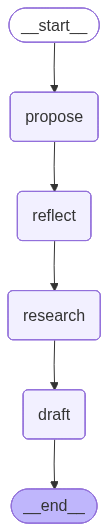

In [13]:

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))